<a href="https://colab.research.google.com/github/balaabirami72-sys/Boston-House-Price-Prediction-using-Regression/blob/main/Boston_House_Price_Prediction_using_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Schedly_Boston_Housing_Unique.csv to Schedly_Boston_Housing_Unique.csv
Loaded File: Schedly_Boston_Housing_Unique.csv

First 5 Rows:
      CRIM   ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  4.01613  0.0   2.10     0  0.726  5.605  19.7  5.1548   24  662     17.6   
1  2.41050  0.0   6.41     0  0.783  4.860  36.1  4.6882    7  344     16.2   
2  6.28489  0.0  24.61     0  0.549  5.437  81.4  3.7737   24  649     20.9   
3  0.11503  0.0  15.69     0  0.688  5.489  47.9  6.4962    2  305     21.3   
4  5.94187  0.0   1.12     0  0.707  7.220  45.1  1.8620    5  298     13.0   

        B  LSTAT  MEDV  
0  373.31  20.32   8.6  
1  216.62   9.48   8.0  
2  322.45  10.47  11.5  
3  113.15  14.79  11.5  
4    9.62  25.30  27.8  

Missing Values After Cleaning:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Model P

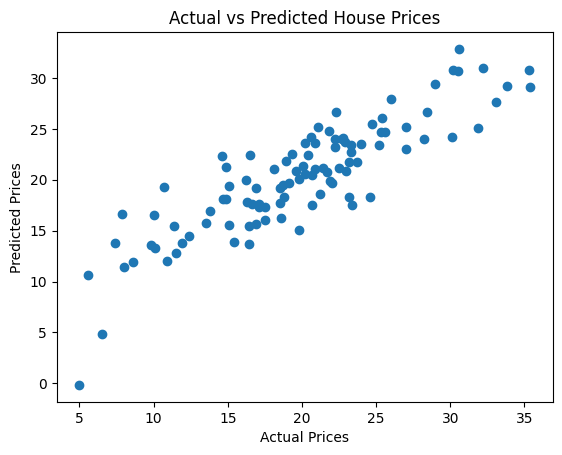

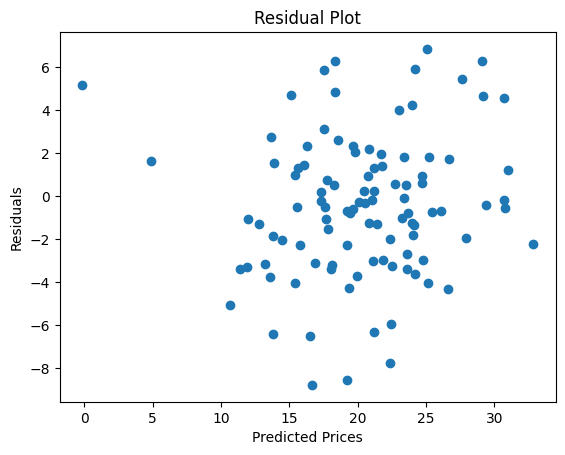

In [2]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ---------------- LOAD DATASET ----------------
file_name = list(uploaded.keys())[0]
print("Loaded File:", file_name)

df = pd.read_csv(file_name)

print("\nFirst 5 Rows:")
print(df.head())

# ---------------- HANDLE MISSING VALUES ----------------
threshold = 0.6 * len(df)
df = df.dropna(thresh=threshold, axis=1)
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ---------------- TARGET COLUMN ----------------
target = "MEDV"   # Boston dataset target column

X = df.drop(target, axis=1)
y = df[target]

# ---------------- TRAIN TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ---------------- TRAIN MODEL ----------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------- PREDICT ----------------
y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error (MSE):", round(mse,4))
print("Root Mean Squared Error (RMSE):", round(rmse,4))
print("R2 Score:", round(r2,4))

# ---------------- ACTUAL VS PREDICTED GRAPH ----------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# ---------------- RESIDUAL PLOT ----------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()